In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.ticker as ticker
import numpy as np
import re
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import json
from matplotlib.patches import Patch
import ast
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

In [98]:
ROOT = Path("results/2026-05-01_105053/measurements")

In [99]:
MCPERF_FILENAME = "mcperf.txt"

rows = []

subfolders = sorted(
    [p for p in ROOT.iterdir() if p.is_dir()],
    key=lambda p: pd.to_datetime(p.name, format="%Y-%m-%d_%H:%M:%S")
)

for iteration, folder in enumerate(subfolders, start=1):
    file = folder / MCPERF_FILENAME

    if not file.exists():
        continue

    df = pd.read_csv(file, sep=r"\s+")

    df["p95"] = df["p95"]/1000

    # print(file)

    rows.append({
        "iteration": iteration,
        "measurement_time": pd.to_datetime(folder.name, format="%Y-%m-%d_%H:%M:%S"),
        "folder": folder.name,
        "file": file.name,
        "mean_p95_latency": df["p95"].mean(),
        "std_p95_latency": df["p95"].std(),
        "num_p95_over_1ms": (df["p95"] > 1).sum(),
        "num_measurements": len(df),
    })

result = pd.DataFrame(rows)

In [100]:
result

,iteration,measurement_time,folder,file,mean_p95_latency,std_p95_latency,num_p95_over_1ms,num_measurements
0,1,2026-05-01 10:57:31,2026-05-01_10:57:31,mcperf.txt,0.403094,0.021777,0,32
1,2,2026-05-01 11:14:45,2026-05-01_11:14:45,mcperf.txt,0.391843,0.014683,0,37
2,3,2026-05-01 11:23:58,2026-05-01_11:23:58,mcperf.txt,0.400316,0.016303,0,32
3,4,2026-05-01 11:32:58,2026-05-01_11:32:58,mcperf.txt,0.397886,0.018094,0,28
4,5,2026-05-01 11:43:24,2026-05-01_11:43:24,mcperf.txt,0.400481,0.012142,0,32
5,6,2026-05-01 12:14:09,2026-05-01_12:14:09,mcperf.txt,0.404164,0.013858,0,33
6,7,2026-05-01 12:22:42,2026-05-01_12:22:42,mcperf.txt,0.402952,0.014562,0,27
7,8,2026-05-01 13:00:27,2026-05-01_13:00:27,mcperf.txt,0.640808,0.165121,0,25
8,9,2026-05-01 13:14:22,2026-05-01_13:14:22,mcperf.txt,0.388356,0.012371,0,27
9,10,2026-05-01 13:21:50,2026-05-01_13:21:50,mcperf.txt,0.399217,0.013880,0,24


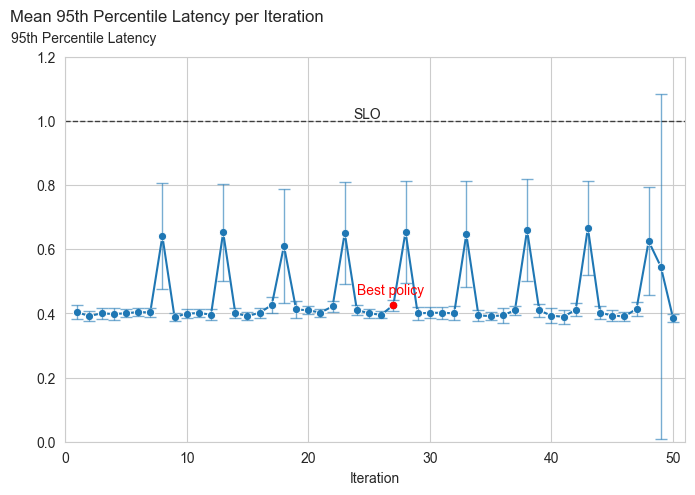

In [101]:
# Seaborn style with grid background
sns.set_style("whitegrid")

# Create line plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=result, x="iteration", y="mean_p95_latency", marker="o")

ax.errorbar(
    result["iteration"],
    result["mean_p95_latency"],
    yerr=result["std_p95_latency"],
    fmt="none",      # no extra markers/line
    capsize=4,        # small caps on error bars
    linewidth=1,   # thinner line
    alpha=0.6 
)

y_mark = result.loc[result["iteration"] == 27, "mean_p95_latency"].iloc[0]

# Mark the point in red
ax.scatter(
    27,
    y_mark,
    color="red",
    s=20,
    zorder=5
)

# Add text next to the point
ax.annotate(
    "Best policy",
    xy=(27, y_mark),      # point being annotated
    xytext=(24, 0.46),           # text position
    textcoords="data",
    color = "red"         # interpret xytext as data coordinates
)

y_ref = 1

ax.axhline(
    y=y_ref,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    color= "black"
)

# Label next to the line
ax.text(
    26,   # x-position
    y_ref,           # y-position
    "SLO",     # text
    va="bottom",     # vertical alignment
    ha="right"       # horizontal alignment
)

ax.set_ylim(0, 1.2)
ax.set_xlim(0, 51)

# Optional labels/title
# plt.title("Mean 95th Percentile Latency per Iteration")
ax.set_title("Mean 95th Percentile Latency per Iteration", x=0.164, y=1.07)
ax.set_ylabel("95th Percentile Latency", rotation=0)
ax.yaxis.set_label_coords(0.03, 1.03)
plt.xlabel("Iteration")

plt.savefig("results/2026-05-01_105053/part3_2_p95_latency.pdf", bbox_inches="tight")
plt.show()

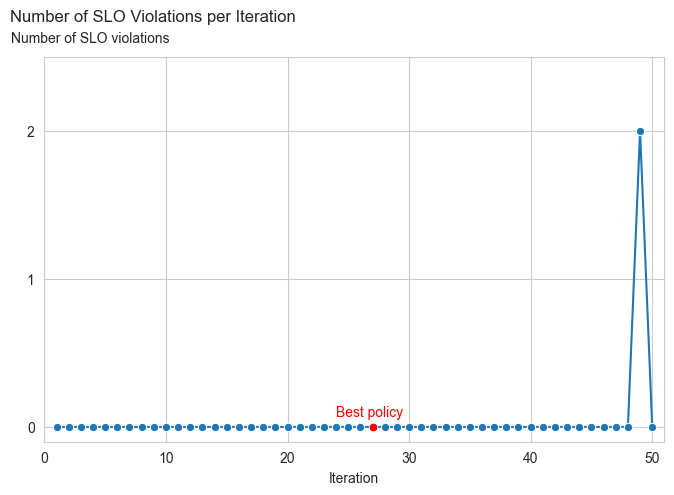

In [102]:
# Seaborn style with grid background
sns.set_style("whitegrid")

# Create line plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=result, x="iteration", y="num_p95_over_1ms", marker="o")

y_mark = result.loc[result["iteration"] == 27, "num_p95_over_1ms"].iloc[0]

# Mark the point in red
ax.scatter(
    27,
    y_mark,
    color="red",
    s=20,
    zorder=5
)

# Add text next to the point
ax.annotate(
    "Best policy",
    xy=(27, y_mark),      # point being annotated
    xytext=(24, 0.07),           # text position
    textcoords="data",
    color = "red"         # interpret xytext as data coordinates
)

ax.set_ylim(-0.1, 2.5)
ax.set_xlim(0, 51)

# Optional labels/title
# plt.title("Mean 95th Percentile Latency per Iteration")
ax.set_title("Number of SLO Violations per Iteration", x=0.175, y=1.07)
ax.set_ylabel("Number of SLO violations", rotation=0)
ax.yaxis.set_label_coords(0.0745, 1.03)
plt.xlabel("Iteration")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.savefig("results/2026-05-01_105053/part3_2_SLO_violations.pdf", bbox_inches="tight")
plt.show()